In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")

print("Setup Complete")

Setup Complete


In [2]:
FIG_DIR = Path("reports/figures")
TABLE_DIR = Path("reports/tables")

FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

print("Folders are ready")

Folders are ready


In [5]:
df = pd.read_csv("saudi_data_jobs_cleaned.csv")

print("Data loaded successfully")
df.head()

Data loaded successfully


,job_id,job_title,company,city,role_type,experience_level,skills,tools,source,job_link,date_collected,notes,city_cleaned,experience_category,role_category
0,1,Data Analyst,ALESAYI HOLDING,Jeddah,Data Analyst,Entry level / 3 years,"customer data analysis, operational performanc...","Excel, PowerPoint, dashboards",LinkedIn,https://sa.linkedin.com/jobs/view/data-analyst...,2026-06-30,Customer experience data analyst role in autom...,Jeddah,Entry Level,Data Analysis
1,2,Geological Data Scientist,Maaden Barrick Copper Company,Mahd Adh Dhahab,Data Scientist,Entry level / 2-5 years,"geological data management, data quality manag...","SQL, Python, Power BI, Tableau, relational dat...",LinkedIn,https://sa.linkedin.com/jobs/view/geological-d...,2026-06-30,Mining sector data science role. Focuses on ge...,Mahd Adh Dhahab,Entry Level,Data Science
2,3,Data Analyst,PrimeGate for Communications and IT,Riyadh,Data Analyst,Entry level,"data analysis, insights generation, dashboardi...","SQL, Power BI, Tableau, Looker, Excel, Python,...",LinkedIn,https://sa.linkedin.com/jobs/view/data-analyst...,2026-06-30,Entry-level data analyst role for Madinaty Sup...,Riyadh,Entry Level,Data Analysis
3,4,Analyst Pricing Analytics and Insights,Schneider Electric,Saudi Arabia,Business / Pricing Analytics,Entry level,"pricing analytics, data analysis, data interpr...","data visualization, dashboards, charts, reports",LinkedIn,https://sa.linkedin.com/jobs/view/analyst-pric...,2026-06-30,Entry-level pricing analytics role. Focuses on...,Not specified,Entry Level,Data Analysis
4,5,Power BI Developer,Acuative Middle East,Jeddah,BI / Power BI Developer,Mid-level,"Power BI dashboard development, business intel...","Power BI Desktop, Power BI Service, DAX, Power...",LinkedIn,https://sa.linkedin.com/jobs/view/power-bi-dev...,2026-06-30,Mid-level Power BI Developer role in Jeddah. F...,Jeddah,Mid-Level,BI


In [6]:
df[["job_title", "role_type", "role_category"]].head(10)

,job_title,role_type,role_category
0,Data Analyst,Data Analyst,Data Analysis
1,Geological Data Scientist,Data Scientist,Data Science
2,Data Analyst,Data Analyst,Data Analysis
3,Analyst Pricing Analytics and Insights,Business / Pricing Analytics,Data Analysis
4,Power BI Developer,BI / Power BI Developer,BI
5,2026 KSA Analyst Program - Data and AI Analyst,Data / AI Analyst,AI
6,Data Scientist I,Data Scientist,Data Science
7,Specialist Operations Performance,Performance / Operations Analytics,Other
8,Data Analyst Fraud Protection,Fraud / Cybersecurity Analytics,Data Analysis
9,Junior Digital Marketing Analyst,Digital Marketing Analytics,Other


In [7]:
print("Number of unique raw role types:")
print(df["role_type"].nunique())

print("\nNumber of unique cleaned role categories:")
print(df["role_category"].nunique())

Number of unique raw role types:
23

Number of unique cleaned role categories:
6


In [8]:
role_category_counts = df["role_category"].value_counts()

role_category_counts

,count
role_category,
Data Analysis,9
Other,5
AI,4
BI,3
Data Science,2
Governance,2


In [9]:
role_category_summary = role_category_counts.reset_index()

role_category_summary.columns = ["role_category", "job_count"]

role_category_summary

,role_category,job_count
0,Data Analysis,9
1,Other,5
2,AI,4
3,BI,3
4,Data Science,2
5,Governance,2


In [10]:
role_category_summary.to_csv(TABLE_DIR / "role_category_counts.csv", index=False)

print("Saved:", TABLE_DIR / "role_category_counts.csv")

Saved: reports/tables/role_category_counts.csv


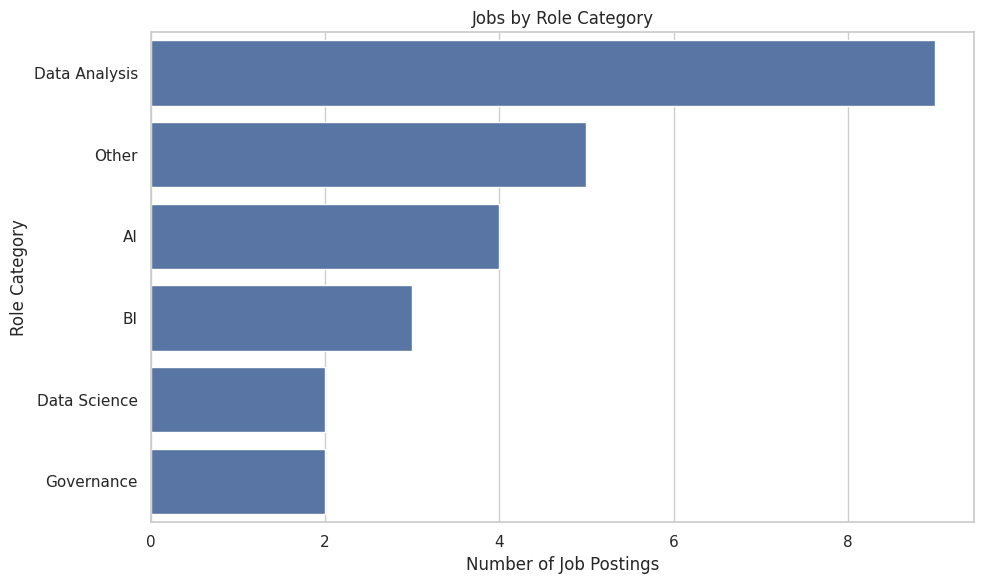

In [11]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=role_category_summary,
    x="job_count",
    y="role_category"
)

plt.title("Jobs by Role Category")
plt.xlabel("Number of Job Postings")
plt.ylabel("Role Category")
plt.tight_layout()

plt.savefig(FIG_DIR / "jobs_by_role_category_bar_chart.png", dpi=300, bbox_inches="tight")

plt.show()

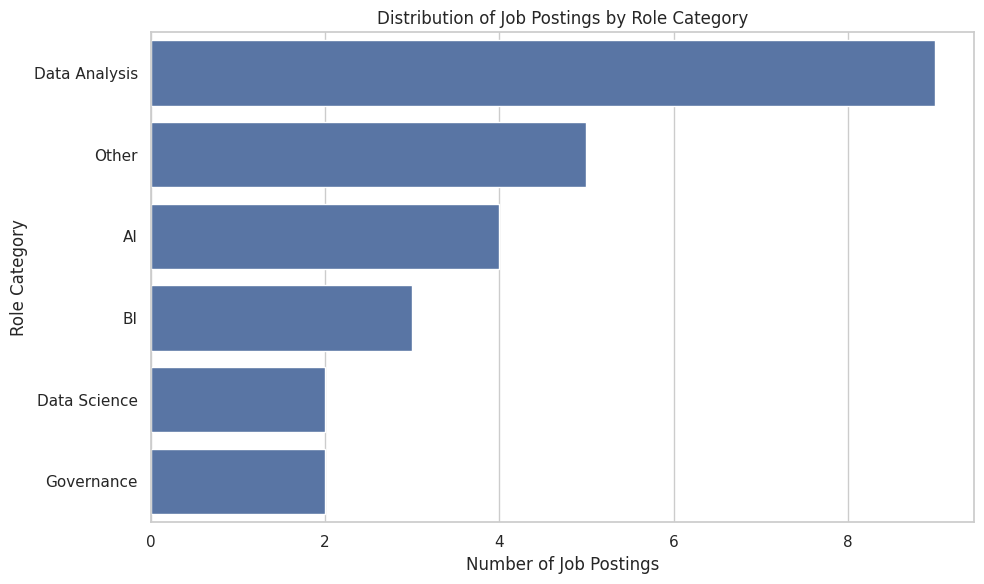

In [12]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    y="role_category",
    order=df["role_category"].value_counts().index
)

plt.title("Distribution of Job Postings by Role Category")
plt.xlabel("Number of Job Postings")
plt.ylabel("Role Category")
plt.tight_layout()

plt.savefig(FIG_DIR / "role_category_countplot.png", dpi=300, bbox_inches="tight")

plt.show()

In [13]:
role_category_summary["percentage"] = (
    role_category_summary["job_count"] / role_category_summary["job_count"].sum() * 100
).round(1)

role_category_summary

,role_category,job_count,percentage
0,Data Analysis,9,36.0
1,Other,5,20.0
2,AI,4,16.0
3,BI,3,12.0
4,Data Science,2,8.0
5,Governance,2,8.0


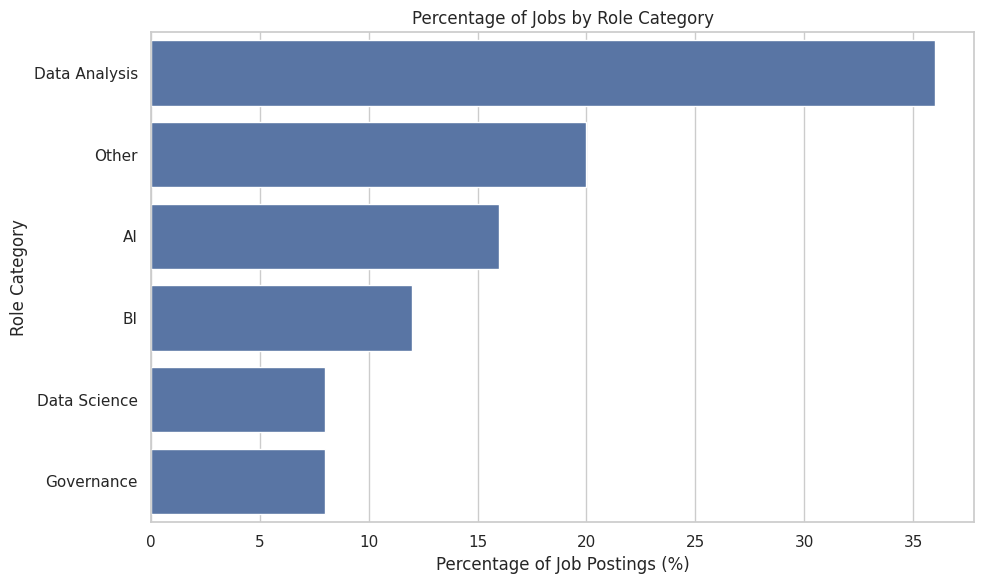

In [14]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=role_category_summary,
    x="percentage",
    y="role_category"
)

plt.title("Percentage of Jobs by Role Category")
plt.xlabel("Percentage of Job Postings (%)")
plt.ylabel("Role Category")
plt.tight_layout()

plt.savefig(FIG_DIR / "role_category_percentage_bar_chart.png", dpi=300, bbox_inches="tight")

plt.show()

In [15]:
role_experience_table = pd.crosstab(
    df["role_category"],
    df["experience_category"]
)

role_experience_table

experience_category,Entry Level,Internship,Mid-Level
role_category,,,
AI,1,2,1
BI,1,0,2
Data Analysis,4,0,5
Data Science,2,0,0
Governance,1,0,1
Other,3,0,2


In [16]:
role_experience_long = role_experience_table.reset_index().melt(
    id_vars="role_category",
    var_name="experience_category",
    value_name="job_count"
)

role_experience_long.head()

,role_category,experience_category,job_count
0,AI,Entry Level,1
1,BI,Entry Level,1
2,Data Analysis,Entry Level,4
3,Data Science,Entry Level,2
4,Governance,Entry Level,1


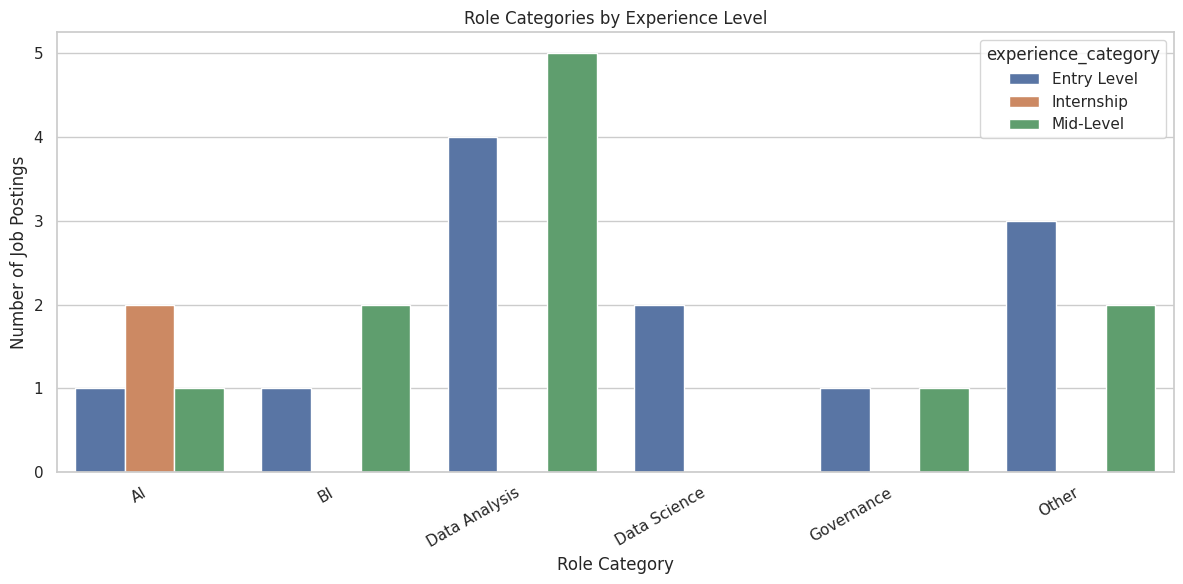

In [17]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=role_experience_long,
    x="role_category",
    y="job_count",
    hue="experience_category"
)

plt.title("Role Categories by Experience Level")
plt.xlabel("Role Category")
plt.ylabel("Number of Job Postings")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()

plt.savefig(FIG_DIR / "role_category_by_experience_bar_chart.png", dpi=300, bbox_inches="tight")

plt.show()

In [18]:
role_mapping_view = df[["job_title", "role_type", "role_category"]].sort_values("role_category")

role_mapping_view.head(25)

,job_title,role_type,role_category
12,Elm Co-op Training Program August 2026 Intake ...,IT / Data-related Internship,AI
5,2026 KSA Analyst Program - Data and AI Analyst,Data / AI Analyst,AI
14,Technical Co-op - Artificial Intelligence,AI / Data-related Internship,AI
23,AI Developer,AI / ML Engineering,AI
4,Power BI Developer,BI / Power BI Developer,BI
18,Capabilities and Insights Analytics Analyst - ...,Healthcare Analytics / AI,BI
17,Business Intelligence Developer,BI / Business Intelligence,BI
21,Data Analytics - Senior Business Analyst,Business / Financial Analytics,Data Analysis
20,Consultant - Research and Analytics,Research / Quantitative Analytics,Data Analysis
19,Flight Data Analysis Officer,Aviation Safety Analytics,Data Analysis


In [19]:
role_mapping_view.to_csv(TABLE_DIR / "role_type_to_role_category_mapping.csv", index=False)

print("Saved:", TABLE_DIR / "role_type_to_role_category_mapping.csv")

Saved: reports/tables/role_type_to_role_category_mapping.csv


In [20]:
top_role = role_category_summary.iloc[0]["role_category"]
top_role_count = role_category_summary.iloc[0]["job_count"]
top_role_percentage = role_category_summary.iloc[0]["percentage"]

print("Day 10 Insight:")
print(f"The most common role category in the dataset is {top_role}.")
print(f"It appeared in {top_role_count} job postings, representing {top_role_percentage}% of the dataset.")
print("\nUsing role_category instead of raw role_type makes the analysis cleaner and easier to explain.")

Day 10 Insight:
The most common role category in the dataset is Data Analysis.
It appeared in 9 job postings, representing 36.0% of the dataset.

Using role_category instead of raw role_type makes the analysis cleaner and easier to explain.


In [21]:
saved_figures = list(FIG_DIR.glob("*.png"))

print("Saved figures:")
for fig in saved_figures:
    print(fig)

Saved figures:
reports/figures/role_category_percentage_bar_chart.png
reports/figures/role_category_by_experience_bar_chart.png
reports/figures/role_category_countplot.png
reports/figures/jobs_by_role_category_bar_chart.png


In [22]:
saved_tables = list(TABLE_DIR.glob("*.csv"))

print("Saved tables:")
for table in saved_tables:
    print(table)

Saved tables:
reports/tables/role_category_counts.csv
reports/tables/role_type_to_role_category_mapping.csv


## Day 10: Role Category Analysis

Today I analyzed the cleaned `role_category` column instead of relying on the raw `role_type` column.

Completed:
- Compared raw role types with cleaned role categories.
- Counted job postings by role category.
- Created bar charts for role category distribution.
- Calculated the percentage of each role category.
- Compared role categories with experience levels.
- Saved charts and analysis tables.

Main takeaway:
Using `role_category` makes the analysis cleaner and easier to explain because it groups similar roles into broader categories such as Data Analysis, Data Science, BI, AI, Governance, Internship, and Other.